Notes:  
Light bar roof deployment  
10/30 - batteries changed on all datalogger, light bars set up on south side of roof. Sun in middle of day but shaded by satellites on either side  
11/3 - Light bars moved to West side of roof. More afternoon sunlight. Likely still shade for most of morning and after about 3 pm. L1 battery died very quickly and L5 is having issue (dying and keyboard not working). Bar 1 plugged into L2 port 1 (bar 2 in port 2). Bar 5 in L6 port 1.  
11/11 - Data downloaded. All working and still have battery power except L4 hasn't collected data since 11/3. Programmed correctly. Tried plugging cable into port 1 instead (and updated program). Swapped Bar 1 for shadowband bar in port 1 of L2.  
11/21 - Pulled all light bars from roof. All dataloggers still alive! Downloaded data.



In [1]:
import numpy as np
import pandas as pd
import datetime as dt
import glob
import fnmatch
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)
pd.set_option('display.max_seq_items', 150)

In [ ]:
'''
Dictionary specifying data file details
Lightbar number: [position short name, position long name, datalogger number until 6/1/2025-11/3/2025, 
column poisition in files , column poisition in files ]
'''
bars = {
    'L1': ['TPE', 'Single-Axis, Under-Panel, East', 'DL1', 1, 'DL2', 1],
    'L2': ['TPW', 'Single-Axis, Under-Panel, West',  'DL2', 1, 'DL2', 2],
    'L3': ['TPM', 'Single-Axis, Under-Panel, Middle', 'DL3', 1, 'DL3', 1],
    'L4': ['TAM','Single-Axis, Alley, Middle', 'DL4', 1, 'DL4', 1],
    'L5': ['FPM', 'Fixed-Tilt, Under-Panel, Middle', 'DL5', 1, 'DL6', 1],
    'L6': ['FPN', 'Fixed-Tilt, Under-Panel, North', 'DL6', 1, 'DL6', 2],
    'L7': ['FAM', 'Fixed-Tilt, Alley, Middle', 'DL7', 1, 'DL7', 1],
    'L8': ['FAN', 'Fixed-Tilt, Alley, North', 'DL8', 1, 'DL8', 1]
}

#Directory with all light bar data
LB_dir = 'C:\\Users\\emily\\Documents\\Grad_School\\Research\\Agrivoltaics\\Data\\Lightbars\\'


In [143]:
def read_DL_file(file, col = 1):
    add_dat = pd.read_csv(file, sep = '\t', usecols = [0,1,1+col], names = ['mes_type', 'TIMESTAMP', 'val'])
    add_dat = add_dat[add_dat['mes_type'] == 1] #Get rid of batter voltage measurement (mes_type = 2)
    add_dat.drop('mes_type', axis = 1, inplace = True) #get rid of mes_type column, not needed anymore
    dt_ts = pd.to_datetime(add_dat['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') 
    add_dat.drop('TIMESTAMP', axis = 1, inplace = True)
    add_dat.set_index(dt_ts, inplace = True)
    add_dat = pd.to_numeric(add_dat['val'], errors= 'coerce') #Turns numeric values into float, non-numeric to NaN
    return add_dat


    # add_dat = pd.read_csv(file, sep = '\t', usecols = [0, 1,2], names = ['TIMESTAMP', 'val'])
    
    # dt_ts = pd.to_datetime(add_dat['TIMESTAMP'], format = '%Y-%m-%d %H:%M:%S') 
    # add_dat.drop('TIMESTAMP', axis = 1, inplace = True)
    # add_dat.set_index(dt_ts, inplace = True)
    # add_dat = pd.to_numeric(add_dat['val'], errors= 'coerce') #Turns numeric values into float, non-numeric to NaN
    # bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data


# Field deployment

In [209]:
#New index w/out missing or repeat timesteps to use for all bars
sd = dt.datetime(2025, 6, 1) #start date: when bars were first deployed in feild 
ed = dt.datetime(2025, 10, 10)#end date: when bars were pulled from feild
r = pd.date_range(start=sd, end=ed, freq = '5min')

lbdat = pd.DataFrame()
for bar in [list(bars.keys())[7]]:
    bar_dat = pd.DataFrame()
    pos = bars[bar][0]
    col = 1
    dat_files = sorted(glob.glob(LB_dir + '*' + pos + '*'))
    for file in dat_files:
        print(file)
        add_dat = read_DL_file(file) #all data in first column for in-field data
        bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data

    #Make continuous time series (no gaps or repreated timetsteps)
    bar_dat = bar_dat.loc[~bar_dat.index.duplicated(keep = 'last')].reindex(r)
    lbdat[bar + '_' + pos] = bar_dat
lbdat_hh = lbdat.resample('30min').mean()


C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\Lightbars\L8_FAN_0801.txt
C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\Lightbars\L8_FAN_0831.txt


C:\Users\emily\AppData\Local\Temp\ipykernel_19176\2082783474.py:15: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data


C:\Users\emily\Documents\Grad_School\Research\Agrivoltaics\Data\Lightbars\L8_FAN_1010.txt


In [201]:
sdcut = dt.datetime(2025, 7, 31, 20)
edcut = dt.datetime(2025, 7, 31, 22)
F0 = read_DL_file(dat_files[0])[sdcut:edcut]
F1 = read_DL_file(dat_files[1])[sdcut:edcut]
bdtest = pd.concat([F0, F1])
bdtest.loc[~bdtest.index.duplicated(keep = 'last')]#.reindex(r)

KeyError: Timestamp('2025-07-31 20:00:00')

TIMESTAMP
2025-07-31 21:30:00    0.000008
2025-07-31 21:35:00    0.000008
2025-07-31 21:40:00    0.000008
2025-07-31 21:45:00    0.000008
2025-07-31 21:50:00    0.000008
2025-07-31 21:55:00    0.000008
2025-07-31 22:00:00    0.000008
Name: val, dtype: float64

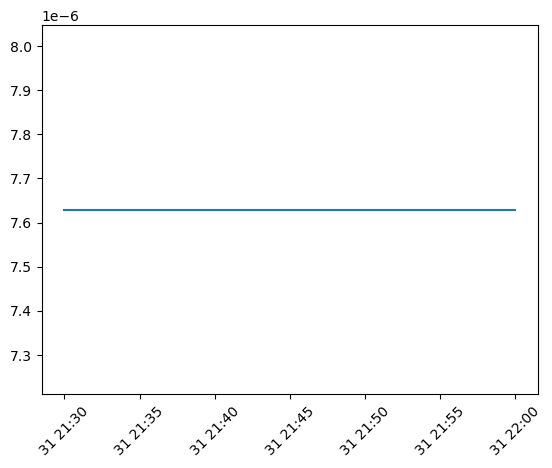

In [196]:
sdcut = dt.datetime(2025, 7, 31, 21, 30)
edcut = dt.datetime(2025, 8, 1, 3)
# sdcut = dt.datetime(2025, 7, 31)
# edcut = dt.datetime(2025, 8, 3)
plt.plot(add_dat[sdcut:edcut])
plt.xticks(rotation = 45)
add_dat[sdcut:edcut]

In [ ]:
#Safe data
lbdat.to_csv(LB_dir + 'all_5min_LB_data_nocal.csv') #5 minute data
lbdat_hh.to_csv(LB_dir + 'all_30min_LB_data_nocal.csv') #30 minute resampled data

# Roof comparison

In [ ]:
#New index w/out missing or repeat timesteps to use for all bars
sd = dt.datetime(2025, 10, 30)#start date - when bars were first deployed on roof
ed = dt.datetime(2025, 11, 21)#end date - when bars were pulled from roof
cd = dt.datetime(2025, 11, 3, ) #change date - date time when LB1 and 5 were plugged into DL2 and 6, respectively
r = pd.date_range(start=sd, end=ed, freq = '5min')

lbdat = pd.DataFrame()
for bar in list(bars.keys()):
    bar_dat = pd.DataFrame()
    DL1_num = bars[bar][4]
    col1 = bars[bar][5]
    dat_files1 = sorted(glob.glob(LB_dir + '*' + DL1_num + '_roof*'))
    for file in dat_files:
        add_dat = read_DL_files(file)
        #Read in each file for one light bar
        if len(add_dat.shape)==1: #Only concats if there is data in add_dat
            bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data

    #Make continuous time series (no gaps or repreated timetsteps)

    bar_dat = bar_dat.drop_duplicates(keep = 'last').reindex(r)
    lbdat[bar] = bar_dat
    lbdat_hh = lbdat.resample('30min')


C:\Users\emily\AppData\Local\Temp\ipykernel_19176\1864386730.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data
C:\Users\emily\AppData\Local\Temp\ipykernel_19176\1864386730.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  bar_dat = pd.concat([bar_dat, add_dat]) #add to rest of data
C:\Users\emily\AppData\Local\Temp\ipykernel_19176\1864386730.py:21: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty it

Next: 
- Figure out how to read in roof data with two bars plugged into one datalogger
- Compare different bars for shorter period of time